In [1]:
import os, json
import numpy as np
import pandas as pd

import joblib
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import xgboost as xgb

RANDOM_STATE = 42
K = 5
N_ATTACK_EXPLAIN = 1000   # 500–1000 is enough for Stage 2
N_FN_EXTRA = 100          # a few false negatives for analysis

# Stage 2 should NOT reload the full CSV for big processed datasets.
# We reuse the processed matrices exported by Notebook 03 (memory-mapped).
X_TEST_PATH = "../outputs/processed/X_test.npy"
Y_TEST_PATH = "../outputs/processed/y_test.npy"

OUT_DIR = "../outputs/stage2/"
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
preprocess = joblib.load("../outputs/preprocess/preprocess.pkl")
xgb_model = joblib.load("../outputs/models/xgboost_baseline.pkl")
logreg_model = joblib.load("../outputs/models/logreg_baseline.pkl")

with open("../outputs/preprocess/feature_names.json", "r", encoding="utf-8") as f:
    FEATURE_NAMES = json.load(f)

print("Loaded artifacts:")
print("- preprocess:", type(preprocess))
print("- XGB:", type(xgb_model))
print("- LogReg:", type(logreg_model))
print("- #features:", len(FEATURE_NAMES))


Loaded artifacts:
- preprocess: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
- XGB: <class 'xgboost.sklearn.XGBClassifier'>
- LogReg: <class 'sklearn.linear_model._logistic.LogisticRegression'>
- #features: 104


In [3]:
# Load processed test set (memmap) — no huge RAM usage
if not (os.path.exists(X_TEST_PATH) and os.path.exists(Y_TEST_PATH)):
    raise FileNotFoundError(
        "Missing processed test matrices. Run notebooks/03_preprocessing_pipeline.ipynb first "
        "to export ../outputs/processed/X_test.npy and y_test.npy."
    )

X_test = np.load(X_TEST_PATH, mmap_mode="r")      # shape (n_test, n_features)
y_test = np.load(Y_TEST_PATH, mmap_mode="r")      # shape (n_test,)

# Ensure expected feature dimension
assert X_test.shape[1] == len(FEATURE_NAMES), "Feature count mismatch vs feature_names.json"

print("Test shapes:", X_test.shape, y_test.shape)

def predict_in_batches(model, X, batch=200_000):
    preds = []
    for i in range(0, X.shape[0], batch):
        Xb = np.asarray(X[i:i+batch], dtype=np.float32)
        preds.append(model.predict(Xb))
    return np.concatenate(preds)



Test shapes: (502628, 104) (502628,)


In [4]:
# Predictions for selection
y_pred_logreg = logreg_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_logreg)
tn, fp, fn, tp = cm.ravel()
print("LogReg confusion matrix [tn fp; fn tp]:", cm)

attack_idx = np.where(y_test == 1)[0]
tp_idx = np.where((y_test == 1) & (y_pred_logreg == 1))[0]
fn_idx = np.where((y_test == 1) & (y_pred_logreg == 0))[0]

print("Attack total:", len(attack_idx))
print("TP attacks:", len(tp_idx))
print("FN attacks:", len(fn_idx))

rng = np.random.default_rng(RANDOM_STATE)

# pick TP subset
n_tp = min(N_ATTACK_EXPLAIN, len(tp_idx))
tp_sample = rng.choice(tp_idx, size=n_tp, replace=False)

# add some FN for analysis (optional)
n_fn = min(N_FN_EXTRA, len(fn_idx))
fn_sample = rng.choice(fn_idx, size=n_fn, replace=False) if n_fn > 0 else np.array([], dtype=int)

S_idx = np.unique(np.concatenate([tp_sample, fn_sample]))
X_S = X_test[S_idx]
y_S = y_test[S_idx]

print("Selected subset size:", len(S_idx), "| TP:", len(tp_sample), "| FN:", len(fn_sample))


LogReg confusion matrix [tn fp; fn tp]: [[ 16429   1598]
 [ 31495 453106]]
Attack total: 484601
TP attacks: 453106
FN attacks: 31495
Selected subset size: 1100 | TP: 1000 | FN: 100


In [5]:
# LogReg contribution per sample: abs(w * x)
w = logreg_model.coef_.ravel().astype(np.float32)  # shape (n_features,)
b = float(logreg_model.intercept_.ravel()[0])

assert w.shape[0] == X_S.shape[1] == len(FEATURE_NAMES)

C_logreg = np.abs(X_S * w)  # shape (n_samples, n_features)

def topk_indices(contrib_mat, k=5):
    # returns indices of top-k per row
    # argpartition is faster than full sort
    idx = np.argpartition(-contrib_mat, kth=k-1, axis=1)[:, :k]
    # sort top-k within each row by contribution
    row_vals = np.take_along_axis(contrib_mat, idx, axis=1)
    order = np.argsort(-row_vals, axis=1)
    return np.take_along_axis(idx, order, axis=1)

topk_logreg = topk_indices(C_logreg, k=K)  # (n_samples, k)
print("LogReg top-k indices shape:", topk_logreg.shape)


LogReg top-k indices shape: (1100, 5)


In [6]:
booster = xgb_model.get_booster()

dmatrix = xgb.DMatrix(X_S, feature_names=FEATURE_NAMES)

# returns (n_samples, n_features + 1) with last column = bias
contribs = booster.predict(dmatrix, pred_contribs=True)

# split bias
C_xgb = np.abs(contribs[:, :-1]).astype(np.float32)  # only feature contributions
topk_xgb = topk_indices(C_xgb, k=K)

print("XGB contrib matrix shape:", C_xgb.shape)
print("XGB top-k indices shape:", topk_xgb.shape)


XGB contrib matrix shape: (1100, 104)
XGB top-k indices shape: (1100, 5)


In [7]:
def aggregate_topk(topk_idx, contrib_mat, feature_names, k=5):
    n_features = len(feature_names)
    freq = np.zeros(n_features, dtype=np.int32)
    mean_abs = np.zeros(n_features, dtype=np.float64)

    # accumulate
    for i in range(topk_idx.shape[0]):
        idx = topk_idx[i]
        freq[idx] += 1
        mean_abs[idx] += contrib_mat[i, idx].sum()

    # convert to frequency percentage
    freq_pct = freq / topk_idx.shape[0] * 100.0

    # mean abs contribution conditioned on appearing in TopK (avoid division by zero)
    mean_abs_cond = np.zeros(n_features, dtype=np.float64)
    nonzero = freq > 0
    mean_abs_cond[nonzero] = mean_abs[nonzero] / freq[nonzero]

    df_out = pd.DataFrame({
        "feature": feature_names,
        "topk_freq_count": freq,
        "topk_freq_pct": np.round(freq_pct, 2),
        "mean_abs_contrib_in_topk": np.round(mean_abs_cond, 6),
    }).sort_values(by=["topk_freq_count", "mean_abs_contrib_in_topk"], ascending=False)

    return df_out

agg_logreg = aggregate_topk(topk_logreg, C_logreg, FEATURE_NAMES, k=K)
agg_xgb    = aggregate_topk(topk_xgb, C_xgb, FEATURE_NAMES, k=K)

top10_logreg = agg_logreg.head(10).reset_index(drop=True)
top10_xgb    = agg_xgb.head(10).reset_index(drop=True)

display(top10_logreg)
display(top10_xgb)

top10_logreg.to_csv(os.path.join(OUT_DIR, "top10_frequency_logreg.csv"), index=False)
top10_xgb.to_csv(os.path.join(OUT_DIR, "top10_frequency_xgb.csv"), index=False)
print("Saved Top-10 frequency tables.")


,feature,topk_freq_count,topk_freq_pct,mean_abs_contrib_in_topk
0,weird_name_NONE,1100,100.00,10.733305
1,proto_tcp,1032,93.82,10.352113
2,ssl_cipher_NONE,930,84.55,10.015780
3,service_NONE,816,74.18,10.302522
4,ssl_version_NONE,517,47.00,9.717373
5,conn_state_REJ,285,25.91,10.856904
6,service_http,186,16.91,9.961508
7,conn_state_S3,125,11.36,12.285625
8,dst_port,70,6.36,9.877217
9,proto_udp,67,6.09,16.528064


,feature,topk_freq_count,topk_freq_pct,mean_abs_contrib_in_topk
0,dst_port,935,85.00,6.639414
1,src_port,853,77.55,6.706891
2,proto_tcp,823,74.82,6.741739
3,src_pkts,582,52.91,6.540595
4,src_ip_bytes,535,48.64,7.003872
5,dst_pkts,378,34.36,6.331165
6,conn_state_REJ,286,26.00,6.824189
7,conn_state_OTH,270,24.55,7.193833
8,dst_ip_bytes,175,15.91,6.356391
9,duration,135,12.27,6.372531


Saved Top-10 frequency tables.


In [8]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b)

def mean_pairwise_jaccard(topk_idx, max_pairs=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = topk_idx.shape[0]
    if n < 2:
        return 0.0

    pairs = []
    for _ in range(max_pairs):
        i, j = rng.integers(0, n), rng.integers(0, n)
        if i != j:
            pairs.append((i, j))

    scores = [jaccard(topk_idx[i], topk_idx[j]) for i, j in pairs]
    return float(np.mean(scores))

stability_logreg = mean_pairwise_jaccard(topk_logreg, max_pairs=2000, seed=RANDOM_STATE)
stability_xgb    = mean_pairwise_jaccard(topk_xgb, max_pairs=2000, seed=RANDOM_STATE)

stability = {
    "k": K,
    "subset_size": int(len(S_idx)),
    "stability_jaccard_logreg": stability_logreg,
    "stability_jaccard_xgb": stability_xgb,
}

print(stability)

with open(os.path.join(OUT_DIR, "stability_summary.json"), "w") as f:
    json.dump(stability, f, indent=2)


{'k': 5, 'subset_size': 1100, 'stability_jaccard_logreg': 0.5846640410550185, 'stability_jaccard_xgb': 0.4075426661892827}


In [9]:
overlaps = [jaccard(topk_xgb[i], topk_logreg[i]) for i in range(len(S_idx))]
overlap_mean = float(np.mean(overlaps))
overlap_std  = float(np.std(overlaps))

overlap_summary = {
    "k": K,
    "overlap_mean_jaccard_xgb_vs_logreg": overlap_mean,
    "overlap_std": overlap_std,
}

print(overlap_summary)

with open(os.path.join(OUT_DIR, "overlap_summary.json"), "w") as f:
    json.dump(overlap_summary, f, indent=2)


{'k': 5, 'overlap_mean_jaccard_xgb_vs_logreg': 0.15575036075036072, 'overlap_std': 0.0819668899212029}


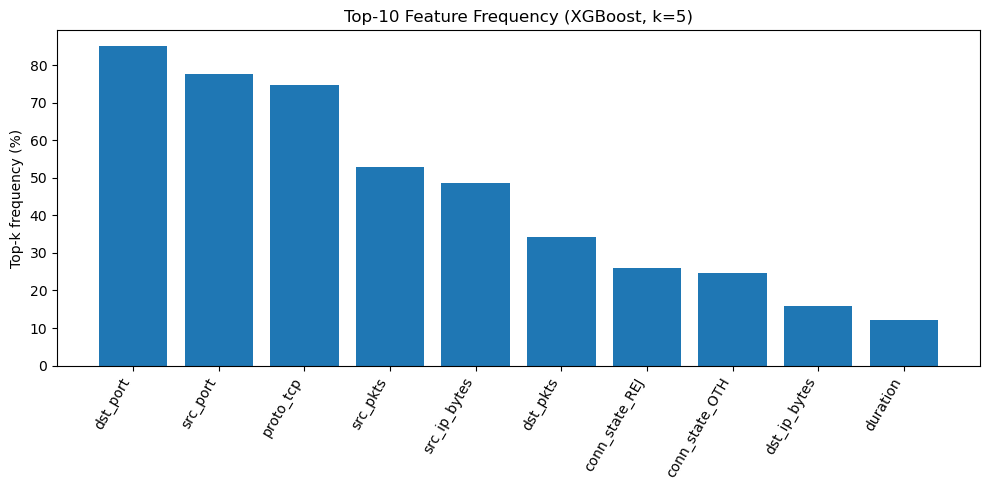

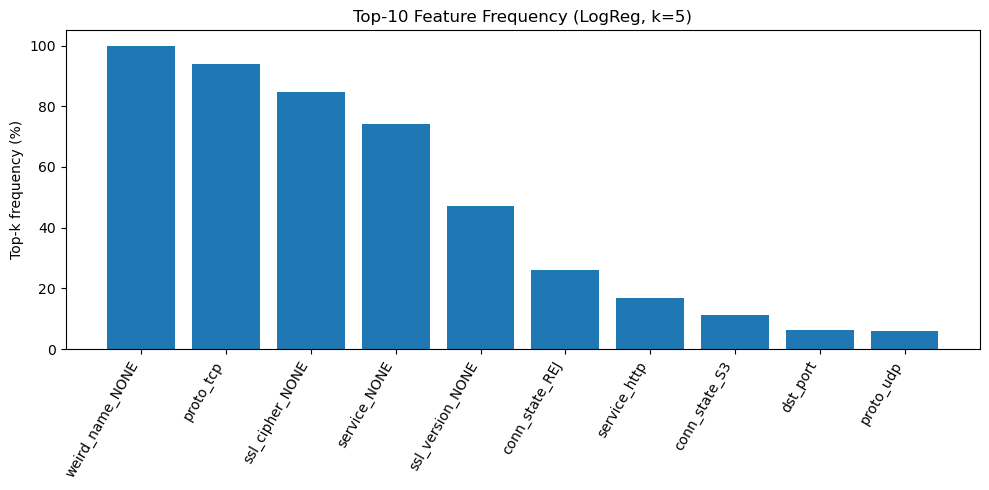

Saved figures to: ../outputs/stage2/


In [10]:
def plot_top10(df_top10, title, out_path):
    plt.figure(figsize=(10, 5))
    plt.bar(df_top10["feature"], df_top10["topk_freq_pct"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Top-k frequency (%)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

plot_top10(top10_xgb, "Top-10 Feature Frequency (XGBoost, k=5)", os.path.join(OUT_DIR, "fig_top10_xgb.png"))
plot_top10(top10_logreg, "Top-10 Feature Frequency (LogReg, k=5)", os.path.join(OUT_DIR, "fig_top10_logreg.png"))

print("Saved figures to:", OUT_DIR)


In [11]:
np.save("../outputs/stage2/topk_xgb.npy", topk_xgb)
np.save("../outputs/stage2/topk_logreg.npy", topk_logreg)
